In [1]:
# !apt-get install gcc 
# !apt-get install -y cmake 

In [2]:
!pip show gcc cmake

Name: cmake
Version: 3.31.6
Summary: CMake is an open-source, cross-platform family of tools designed to build, test and package software
Home-page: https://cmake.org
Author: 
Author-email: Jean-Christophe Fillion-Robin <jchris.fillionr@kitware.com>
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: 
Required-by: 


In [3]:
## -- Check for 3rd party libraries --
try:
    import xlearn
    import skrub
except:
    %pip install -q xlearn>=0.40
    %pip install -q skrub

    import xlearn
    import skrub

xlearn.hello()

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 7.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


# **JAX ACCELERATOR INSTALLATION**

In [4]:
# CPU Only (Default)
# !pip install jax-sklearn[jax-cpu]

# # NVIDIA GPU (CUDA 12)
# pip install jax-sklearn[jax-gpu]

# # Google Cloud TPU
# pip install jax-sklearn[jax-tpu]

# # Apple Silicon (M1/M2/M3/M4)
# pip install jax-sklearn[jax-metal]

## AUTO-DETECT HARDWARE

In [5]:
# from xlearn._jax import jax_config, get_installation_command, detect_hardware

# # Get recommended install command for your hardware
# print(get_installation_command())
# # Output: uv pip install jax-sklearn[jax-metal]  # On Apple Silicon

# # Get detailed hardware info
# info = detect_hardware()
# print(f"Platform: {info['jax_status']['backend']}")

## JAX CONFIGURATION

In [6]:
# GPU/TPU users (DEFAULT - best for most cases)
# JAX always enabled, maximum acceleration
# jax_config.set_config(enable_jax=True)

# CPU users with mixed workload sizes
# Enable threshold to avoid slowdown on medium data
# jax_config.set_config(enable_jax=True, jax_auto_threshold=True)

# Disable JAX completely (use pure sklearn)
# jax_config.set_config(enable_jax=False)


In [7]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [8]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools
import shutil

## -- Machine Learning --
import sklearn
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, KBinsDiscretizer, QuantileTransformer
from sklearn.calibration import CalibrationDisplay

import warnings

In [9]:
import tensorflow as tf

print(tf.__version__)
print("Built with CUDA:", tf.test.is_built_with_cuda())
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

2026-03-10 01:18:49.329166: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773105529.676278      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773105529.779610      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773105530.544105      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773105530.544168      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773105530.544172      17 computation_placer.cc:177] computation placer alr

2.19.0
Built with CUDA: True
GPU available: False


2026-03-10 01:19:07.606173: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [10]:
## -- Global Settings --
# sklearn.set_config(transform_output="pandas")
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [11]:
## -- LOAD DATA --
PATH = '/kaggle/input/competitions/playground-series-s6e3/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/sylvesterdalmeida/telco-customer-churn/'
orig = pd.read_csv(ORIG_PATH+'WA_Fn-UseC_-Telco-Customer-Churn.csv').drop(['customerID'], axis=1)

TARGET = train.columns[-1]
NUMS   = ['tenure', 'MonthlyCharges', 'TotalCharges']
CATS   = [c for c in train.columns if c not in NUMS+[TARGET, 'id']] 
BASE   = NUMS + CATS

for df in [train, orig]:
    df[TARGET] = df[TARGET].map({'Yes': 1, 'No': 0})

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (594194, 20)
Test shape: (254655, 19)
Original shape: (7043, 20)

Total Numerical: 3
Total Categorical: 16
Total base features: 19


In [12]:
## -- FIX ORIGINAL COLUMN --
orig['TotalCharges'] = orig['TotalCharges'].replace(' ', np.nan).astype(float)
orig['TotalCharges'] = orig['TotalCharges'].fillna(orig['TotalCharges'].median())

display(orig.head())
orig.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [13]:
display(train.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,1


In [14]:
train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057,0.225208
std,0.317936,25.061922,31.067444,2353.916710,0.417719
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,12.000000,29.900000,639.650000,0.000000
50%,0.000000,35.000000,74.100000,1433.650000,0.000000
75%,0.000000,62.000000,90.800000,4263.800000,0.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [15]:
round(175.65, -2)

200.0

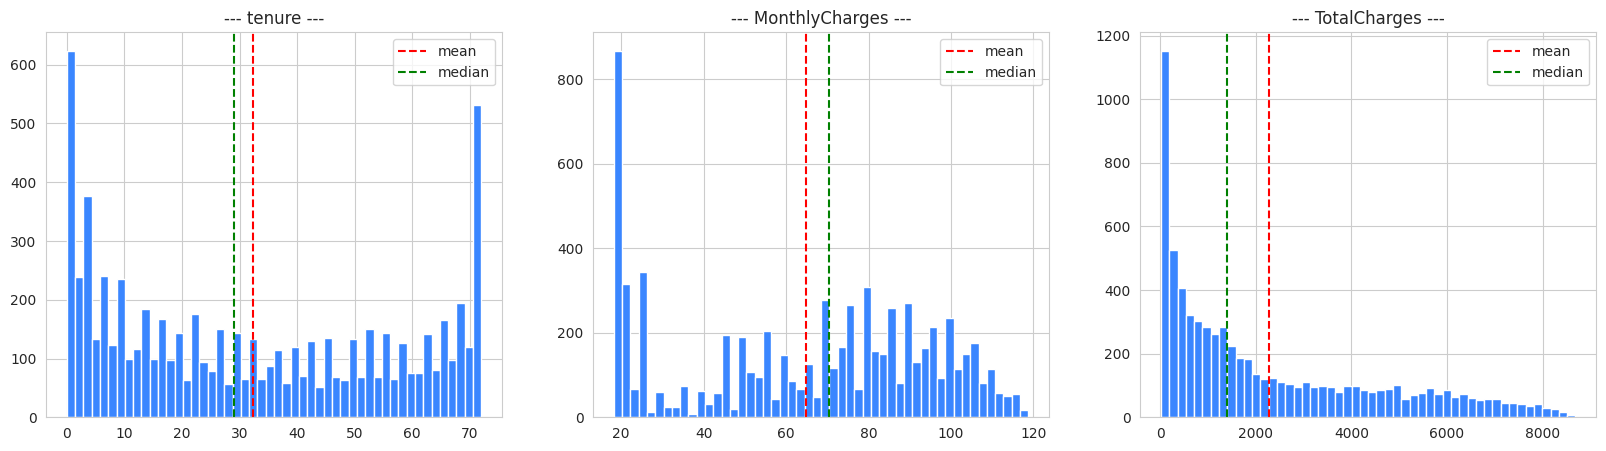

In [16]:
plt.figure(figsize=(20, 5))
for i, col in enumerate(NUMS):
    plt.subplot(1, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()
    
plt.show()

In [17]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,tenure,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
Train,72,1921,31910,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Original,73,1585,6531,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
Test,72,1875,24995,2,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4


In [18]:
os.environ['USER'] = 'bill'

## FEATURE ENGINEERING

In [19]:
# for df_temp in [train, test, orig]:

#     df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
#     df_temp['study_hours_cubed'] = df_temp['study_hours'] ** 3
#     df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
#     df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2
#     df_temp['age_squared'] = df_temp['age'] ** 2

#     df_temp['log_study_hours'] = np.log1p(df_temp['study_hours'])
#     df_temp['log_class_attendance'] = np.log1p(df_temp['class_attendance'])
#     df_temp['log_sleep_hours'] = np.log1p(df_temp['sleep_hours'])
#     df_temp['sqrt_study_hours'] = np.sqrt(df_temp['study_hours'])
#     df_temp['sqrt_class_attendance'] = np.sqrt(df_temp['class_attendance'])

#     ## -- Interaction features --
#     df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
#     df_temp['study_hours_times_sleep'] = (df_temp['study_hours'] * df_temp['sleep_hours'])
#     df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

#     ## -- Ratio features (add small epsilon to avoid division by zero) --
#     eps = 1e-6
#     df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
#     df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)

#     # -- Feature by: Vladimir Demidov
#     # -- https://www.kaggle.com/competitions/playground-series-s6e1/discussion/665915
#     LUT = {
#         'sleep_quality': {'good': 5, 'average': 0, 'poor': -5},
#         'facility_rating': {'high': 4, 'medium': 0, 'low': -4},
#         'study_method': {
#             'coaching': 10,
#             'mixed': 5,
#             'group study': 2,
#             'online videos': 1,
#             'self-study': 0
#         }
#     }

#     df_temp['formula'] = 6 * df_temp['study_hours'] + 0.35 * df_temp['class_attendance'] \
#             + 1.5 * df_temp['sleep_hours'] + \
#             + df_temp['sleep_quality'].map(LUT['sleep_quality']) \
#             + df_temp['study_method'].map(LUT['study_method']) \
#             + df_temp['facility_rating'].map(LUT['facility_rating'])

#     ## -- Encode categorical variables to numeric ordinal values --
#     ordinal_maps = {
#         "internet_access": {"no":0, "yes":1},
#         "gender": {"male":0, "female":1, "other":2},
#         "sleep_quality": {"poor":0, "average":1, "good":2},
#         "facility_rating": {"low":0, "medium":1, "high":2},
#         "exam_difficulty": {"easy":0, "moderate":1, "hard":2},
#         "course": {"ba":0, "b.sc":1, "diploma":2, "b.tech":3, "b.com":4, "bca":5, "bba":6},
#         "study_method": {"self-study":0, "online videos":1, "group study":2, "mixed":3, "coaching":4},
#     }

#     for c in CATS:
#         df_temp[c] = df_temp[c].map(ordinal_maps[c]).fillna(-1)

#     ## -- Interaction between encoded categoricals and key numeric features --
#     df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality']
#     df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating']
#     df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty']
#     df_temp['age_times_study_hours'] = df_temp['age'] * df_temp['study_hours']
#     df_temp['age_times_attendance'] = df_temp['age'] * df_temp['class_attendance']

#     ## -- Composite feature: learning efficiency --
#     df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)
#     df_temp["study_efficiency"] = df_temp["study_hours"] * (df_temp["class_attendance"] / 100.0)

#     ## -- Cyclic encoding --
#     for p in [12, 14]: # 365//2, 365, 365*2, 365*4
#         df_temp[f"study_hours_sin_{p}"] = np.sin(2 * np.pi * df_temp['study_hours'] / p).astype('float32')
#         df_temp[f"class_attend_sin_{p}"] = np.sin(2 * np.pi * df_temp['class_attendance'] / p).astype('float32')

#     total_features = [c for c in df_temp.columns if c != TARGET]
#     print(f'Feature Engineered: {len(total_features)}')


In [20]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique', 
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the 
        global mean. If 'auto', an empirical Bayes estimate is used.
        
    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping
        
        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)
        
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)
        
        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]
            
            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'
                    
                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)
                    
                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()
                        
                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups
                        
                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)
                    
                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]
            
        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)
            
        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category', 'object']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [21]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [22]:
## -- CONVERT DATAFRAME TO .libffm FORMAT --
from collections import defaultdict

field_features   = defaultdict()

def df_to_libffm(df, cats, nums, target, save_file=f'df_converted.libffm'):
    '''
    Converts pandas dataframe to libffm formats, with feature dimension casting.
    '''
    categories       = cats
    categories_index = dict(zip(categories, range(len(categories))))
    max_val          = 1

    with open(save_file, 'a') as the_file:
        for t in tqdm(range(len(df))):
            row = df.iloc[t]
            label = [str(int(row[target]))]
            ffeatures = []
            for field in categories:
                if field == target:
                    continue 
                feature = row[field]
                if field not in nums:
                    ff = field + '_____' + str(feature)
                    value = 1
                else:
                    ff = field + '_____' + str(0)
                    value = feature
                if ff not in field_features:
                    if len(field_features) == 0:
                        field_features[ff] = 1
                        max_val = max_val + 1
                    else:
                        field_features[ff] = max_val + 1
                        max_val = max_val + 1
                fnum = field_features[ff]
                ffeatures.append('{}:{}:{}'.format(categories_index[field],fnum,value))
            line = label + ffeatures
            the_file.write('{}\n'.format(' '.join(line)))

In [23]:
%%writefile convert_libffm_format.py

## -- CONVERT DATAFRAME TO .libffm FORMAT --
import os
import shutil
import tempfile
import warnings
import numpy as np

def df_to_libffm_format(X, y, filepath='data.libffm', fields=None):
    """ Write data to xlearn format (libsvm or libffm). Modified from
    https://github.com/scikit-learn/scikit-learn/blob/a24c8b46/sklearn/datasets/svmlight_format.py

    :param X: array-like
              Feature matrix in numpy or sparse format
    :param y: array-like
              Label in numpy or sparse format
    :param filepath: file location for writing data to
    :param fields: An array specifying fields in each columns of X. It should have same length 
        as the number of columns in X. When set to None, convert data to libsvm format else
        libffm format.
    """

    with open(filepath, "wb") as f_handle:
        X_is_sp = int(hasattr(X, "tocsr"))
        y_is_sp = int(hasattr(y, "tocsr"))

        if X.dtype.kind == 'i':
            value_pattern = u"%d:%d"
        else:
            value_pattern = u"%d:%.16g"

        if fields is not None:
            is_ffm_format = True
            value_pattern = u"%d:" + value_pattern
        else:
            is_ffm_format = False

        if y.dtype.kind == 'i':
            label_pattern = u"%d"
        else:
            label_pattern = u"%.16g"

        line_pattern = u"%s %s\n"

        for i in range(X.shape[0]):
            if X_is_sp:
                span = slice(X.indptr[i], X.indptr[i + 1])
                x_indices = X.indices[span]
                row = zip(fields[x_indices], x_indices, X.data[span]) if is_ffm_format \
                    else zip(x_indices, X.data[span])
            else:
                nz = X[i] != 0
                row = zip(fields[nz], np.where(nz)[0], X[i, nz]) if is_ffm_format \
                    else zip(np.where(nz)[0], X[i, nz])

            if is_ffm_format:
                s = " ".join(value_pattern % (f, j, x) for f, j, x in row)
            else:
                s = " ".join(value_pattern % (j, x) for j, x in row)

            if y_is_sp:
                labels_str = label_pattern % y.data[i]
            else:
                labels_str = label_pattern % y[i]

            f_handle.write((line_pattern % (labels_str, s)).encode('ascii'))

Writing convert_libffm_format.py


In [24]:
# xtra_train = pd.read_csv(ORIG_PATH+'AutoGluon_TRAIN_ORIG_COL.csv')
# xtra_test  = pd.read_csv(ORIG_PATH+'AutoGluon_TEST_ORIG_COL.csv')

# for df in [xtra_train, xtra_test]:
#     df.columns = ['AutoGluon_ORIG_COL']

# print(xtra_train.shape, xtra_test.shape)

# ## -- CONCATENATE PREDICTED --
# train = pd.concat([train, xtra_train], axis=1)
# test  = pd.concat([test, xtra_test], axis=1)

# print(f"\nTrain shape: {train.shape}\nTest shape : {test.shape}")
# train.head(3)

In [25]:
# train, test, _, NEW_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.sample(1000),
#     features=BASE,
#     target=TARGET,
#     ## --- (count, mean, count, std, skew, nunique, median, max, min)
#     aggs=['mean'],
#     fill_nan=True,
# )

# print(NEW_COLS)

In [26]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []

In [27]:
print(f"\nEXTRACTING ROUNDS... ", end='')
for col in ['TotalCharges']:
    for r in [-3, -2, -1, 0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)

    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nCREATING E_BINS... ", end='')
    for b in [400]: # 100, 500, 1000
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [1000]: # 100, 500, 1000
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)
        
print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS)}')
print(f"✅ TOTAL DIGITS EXTRACTED: {len(DIGITS)}")
print(f"✅ TOTAL EQUAL E_BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE E_BINS: {len(Q_BINS)}")


EXTRACTING ROUNDS... TotalCharges_round_-3, TotalCharges_round_-2, TotalCharges_round_-1, TotalCharges_round_0, TotalCharges_round_1, 
EXTRACTING DIGITS... TotalCharges_digit_-3, TotalCharges_digit_-2, TotalCharges_digit_-1, TotalCharges_digit_0, TotalCharges_digit_1, TotalCharges_digit_2, 
CREATING E_BINS... TotalCharges_bin_400, 
QUANTILE BINNING... TotalCharges_Qbin_1000, 
✅ TOTAL ROUND FEATURES: 5
✅ TOTAL DIGITS EXTRACTED: 6
✅ TOTAL EQUAL E_BINS: 1
✅ TOTAL QUANTILE E_BINS: 1


In [28]:
for col in ['MonthlyCharges']:
    print(f"\nROUNDING FEATURES... ", end='')
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')

        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)
            
    print(f"\nEQUAL BINNING... ", end='')
    for b in [100]: # 50, 100, 400
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)
        
    print(f"\nQUANTILE BINNING... ", end='')
    for q in [500]: # 50, 100, 400
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f"✅ TOTAL DIGITS: {len(DIGITS)}")
print(f'✅ TOTAL ROUNDs: {len(ROUNDS)}')
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS)}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS)}")


ROUNDING FEATURES... MonthlyCharges_round_-2, MonthlyCharges_round_-1, MonthlyCharges_round_0, 
EXTRACTING DIGITS... MonthlyCharges_digit_-2, MonthlyCharges_digit_-1, MonthlyCharges_digit_0, MonthlyCharges_digit_1, MonthlyCharges_digit_2, 
EQUAL BINNING... MonthlyCharges_bin_100, 
QUANTILE BINNING... MonthlyCharges_Qbin_500, 
✅ TOTAL DIGITS: 11
✅ TOTAL ROUNDs: 7
✅ TOTAL EQUAL BINS: 2
✅ TOTAL QUANTILE BINS: 2


In [29]:
for col in ['tenure']:
    print(f"\nEXTRACTING ROUNDS... ", end='')
    for r in [-1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() <= 2:
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        elif train[r_n].nunique() == train[col].nunique():
            train = train.drop([r_n], axis=1)
            test  = test.drop([r_n], axis=1)
            orig  = orig.drop([r_n], axis=1)
        else:
            ROUNDS.append(r_n)
    # print()
    print(f"\nEXTRACTING DIGITS... ", end='')
    for d in [-1, 0]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int32')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int32')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int32')
        ## -- Drop constant features --
        if train[d_n].nunique() < 2:
            train = train.drop([d_n], axis=1)
            test  = test.drop([d_n], axis=1)
            orig  = orig.drop([d_n], axis=1)
        else:
            DIGITS.append(d_n)

    print(f"\nEQUAL BINNING... ", end='')
    for b in [10, 50, 100]:
        b_n = f'{col}_bin_{b}'
        print(b_n+', ', end='')
        # Fit on train data and transform both train and test
        train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
        test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        E_BINS.append(b_n)

    print(f"\nQUANTILE BINNING... ", end='')
    for q in [10, 50, 100]:
        q_n = f'{col}_Qbin_{q}'
        print(q_n+', ', end='')
        train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
        test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
        orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
        Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ TOTAL ROUND FEATURES: {len(ROUNDS):<10}')
print(f"✅ TOTAL DIGITS FEATURES: {len(DIGITS):<10}")
print(f"✅ TOTAL EQUAL BINS: {len(E_BINS):<10}")
print(f"✅ TOTAL QUANTILE BINS: {len(Q_BINS):<10}")


EXTRACTING ROUNDS... tenure_round_-1, 
EXTRACTING DIGITS... tenure_digit_-1, tenure_digit_0, 
EQUAL BINNING... tenure_bin_10, tenure_bin_50, tenure_bin_100, 
QUANTILE BINNING... tenure_Qbin_10, tenure_Qbin_50, tenure_Qbin_100, 
✅ TOTAL ROUND FEATURES: 8         
✅ TOTAL DIGITS FEATURES: 13        
✅ TOTAL EQUAL BINS: 5         
✅ TOTAL QUANTILE BINS: 5         


In [30]:
E_BINS, Q_BINS

(['TotalCharges_bin_400',
  'MonthlyCharges_bin_100',
  'tenure_bin_10',
  'tenure_bin_50',
  'tenure_bin_100'],
 ['TotalCharges_Qbin_1000',
  'MonthlyCharges_Qbin_500',
  'tenure_Qbin_10',
  'tenure_Qbin_50',
  'tenure_Qbin_100'])

In [31]:
# train[E_BINS[-3]].value_counts(dropna=False)#[-50:]

In [32]:
## -- Arithmetic interaction --
for df in [train, test, orig]:
    df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
    df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
    df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
    df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
              '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

train[arithmetic].head()

,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq
0,0.036339,57.029308,1.053844,27.518303,841.0
1,0.018395,65.141380,1.066910,54.362591,3364.0
2,0.017188,100.712929,0.996893,58.180775,3364.0
3,0.985856,70.699928,0.985857,1.014347,1.0
4,1.000000,70.449928,1.000001,1.000000,1.0


In [33]:
## -- Cyclic encoding --
for df in [train, test, orig]:
    for p in [12, 30]:
        df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
        df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [34]:
# train['MonthlyCharges'].rolling(window=10000).mean().plot(figsize=(20, 5))

In [35]:
## -- FREQUENCY ENCODING --
NUMS_FREQ = []
print(f"\nCREATING FREQUENCIES... ", end='')
for col in NUMS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_FREQ'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    NUMS_FREQ.append(n)
    
print()
print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")


CREATING FREQUENCIES... tenure_FREQ, MonthlyCharges_FREQ, TotalCharges_FREQ, 
✅ TOTAL FREQUENCY FEEATURES: 3


In [36]:
# train[NUMS_FREQ].head(), train[NUMS_FREQ].nunique()

In [37]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 62


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_round_-3,TotalCharges_round_-2,TotalCharges_round_-1,TotalCharges_round_0,TotalCharges_round_1,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_round_-1,MonthlyCharges_round_0,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_round_-1,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_bin_100,tenure_Qbin_10,tenure_Qbin_50,tenure_Qbin_100,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,tenure_FREQ,MonthlyCharges_FREQ,TotalCharges_FREQ
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0,2000,1700,1650,1654,1653,1,6,5,3,8,5,75,538,60,60,0,6,0,1,0,41,133,30,2,9,3,19,39,4,19,26,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.009377,0.000207,0.000021
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0,4000,3800,3780,3778,3778,3,7,7,8,2,0,173,716,70,70,0,6,9,5,0,50,159,60,5,8,8,40,80,7,32,52,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,0.009408,0.001234,0.000112
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0,6000,5800,5840,5841,5841,5,8,4,1,3,5,268,863,100,100,1,0,0,4,0,81,366,60,5,8,8,40,80,7,32,52,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.009408,0.000974,0.000150


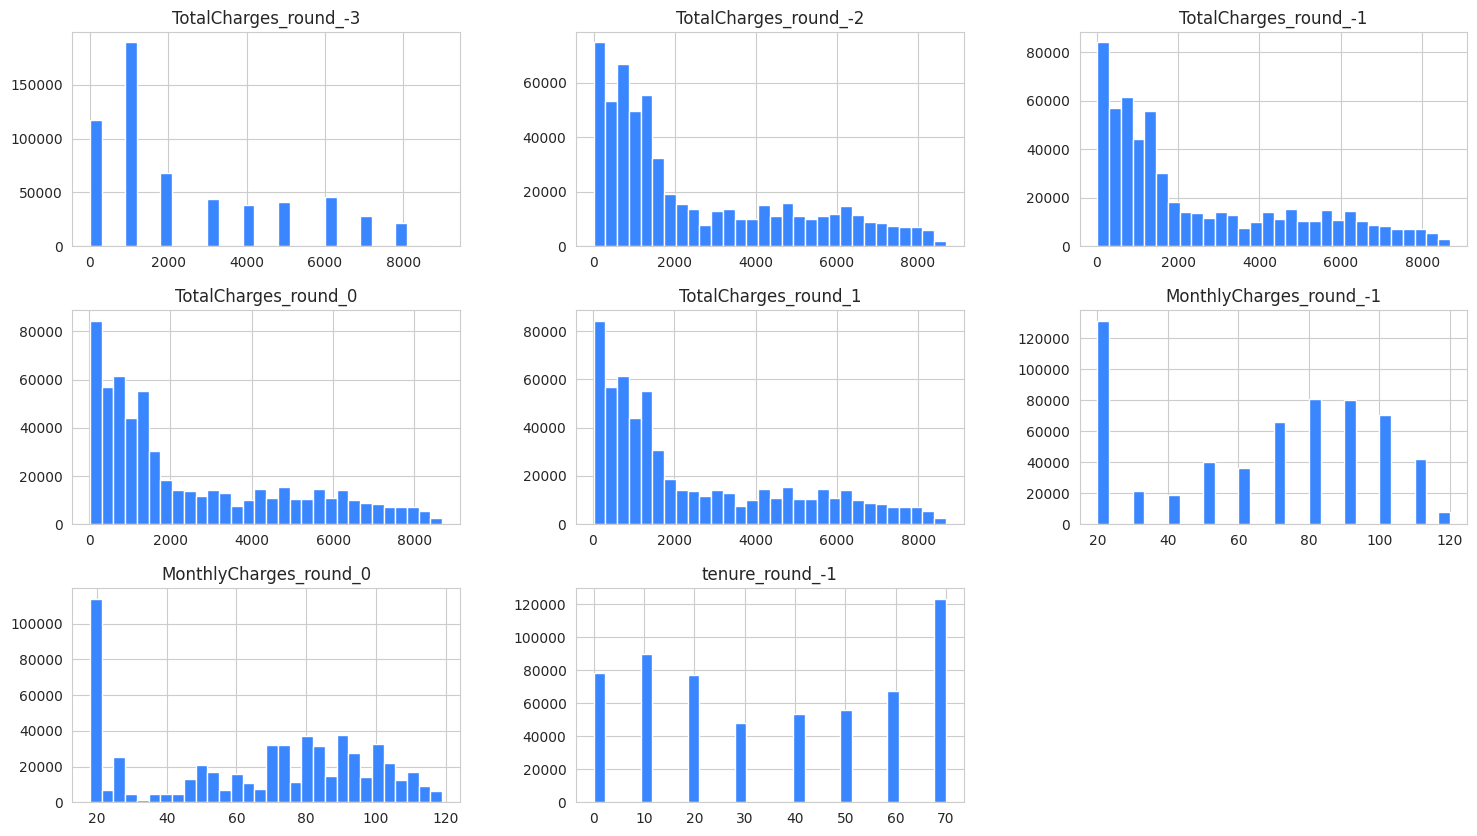

In [38]:
train[ROUNDS].hist(bins=30, figsize=(18, 10), layout=(3, 3))
plt.show()

# ML TRAINING

In [39]:
def Trainer_CV(model_name, params, arch_type, train_df, test_df, features, target, kf):
    print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
    start = time()

    oof_preds = np.zeros(len(train_df))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} - ", end='')

        # Split data for the current fold
        X_train, X_val = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
        y_train, y_val = train_df.loc[train_idx, target], train_df.loc[val_idx, target]

        X_test = test_df[features].copy()

        # ## -- OPTION A: CONCATENATE ORIGINAL DATA --
        # X_train = pd.concat([X_train, orig[features]], ignore_index=True)
        # y_train = pd.concat([y_train, orig[target]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, NEW_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean'], # mean, count, std, nunique, median, max, min
        #     fill_nan=True,
        # )

        # cme = CategoryMeanTransformer(cat_cols=ROUNDS)
        # X_train = cme.fit_transform(X_train, y_train)
        # X_val   = cme.transform(X_val)
        # X_test  = cme.transform(X_test)

        cme_cats = ROUNDS + CATS
        cme_cols = []
        print(f"CategoryMeanEncoding: {len(cme_cats)} | ", end='')
        for c in cme_cats:
            # n = f"CME_{c}"
            cme = CategoryMeanTransformer(cat_cols=[c])
            X_train[c] = cme.fit_transform(X_train[[c]], y_train)
            X_val[c]   = cme.transform(X_val[[c]])
            X_test[c]  = cme.transform(X_test[[c]])
            cme_cols.append(c)
        print()

        for c in ['tenure']:
            n = f"cme_{c}"
            cme_1 = CategoryMeanTransformer(cat_cols=[c])
            X_train[n] = cme_1.fit_transform(X_train[[c]], y_train)
            X_val[n]   = cme_1.transform(X_val[[c]])
            X_test[n]  = cme_1.transform(X_test[[c]])
            # cme_cols.append(n)
        print()

        ROUND_BINS = []
        print(f"\nBINNING ROUND FEATURES... ", end='')
        for c in ROUNDS:
            for b in [500, 1000]:
                r_n = f'{c}_bin_{b}'
                print(r_n+', ', end='')
                # Fit on train data and transform both train and test
                X_train[r_n], edges = pd.cut(X_train[c], bins=b, retbins=True, include_lowest=True, labels=False)
                X_val[r_n]  = pd.cut(X_val[c], bins=edges, include_lowest=True, labels=False)
                X_test[r_n] = pd.cut(X_test[c], bins=edges, include_lowest=True, labels=False)
                ROUND_BINS.append(r_n)
        print()

        for col in ['MonthlyCharges', 'TotalCharges']: # + ROUNDS
            scaler = StandardScaler()
            X_train[col] = scaler.fit_transform(X_train[[col]], y_train)
            X_val[col]   = scaler.transform(X_val[[col]])
            X_test[col]  = scaler.transform(X_test[[col]])

        # ## -- TE Opt1. -> Using CUSTOM --
        # TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        # X_train = TE.fit_transform(X_train, pd.Series(y_train))
        # X_val   = TE.transform(X_val)
        # X_test  = TE.transform(X_test)

        ## -- TE Opt1. -> Using CUSTOM --
        TE = TargetEncoder(ROUNDS, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = TE.fit_transform(X_train, pd.Series(y_train))
        X_val   = TE.transform(X_val)
        X_test  = TE.transform(X_test)

        # te_cols = [c for c in X_train.columns if c.startswith('OTE_')]

        # vector = skrub.TableVectorizer()
        # X_train = vector.fit_transform(X_train)
        # X_val = vector.transform(X_val)
        # X_test = vector.transform(X_test)

        # print(f"Vectorized shape: {X_train.shape} -")

        print(f"Train shape: {X_train.shape} | -")
        display(X_train.head(3))

        all_cats = CATS + DIGITS + E_BINS + Q_BINS + ['tenure'] + ROUND_BINS
        all_nums = [c for c in X_train.columns if c not in all_cats]

        PATH_TRAIN = f"X_train_{idx}.libffm"
        df_to_libffm(pd.concat([X_train, y_train], axis=1), all_cats, all_nums, TARGET, PATH_TRAIN)

        PATH_VAL = f"X_val_{idx}.libffm"
        df_to_libffm(pd.concat([X_val, y_val], axis=1), all_cats, all_nums, TARGET, PATH_VAL)

        if arch_type == 'fm':
            model = xlearn.create_fm()
        elif arch_type == 'ffm':
            model = xlearn.create_ffm()
        else:
            model = xlearn.create_linear()

        model.setTrain(PATH_TRAIN)   
        model.setValidate(PATH_VAL)
        
        # model.setQuiet()
        model.disableLockFree()
        # model.disableEarlyStop()
        # model.disableNorm()

        PATH_MODEL = f'model_{idx}.out'
        model.fit(params, PATH_MODEL)

        ## =========== VALIDATE PERFORMANCE ============ 
        model = xlearn.create_linear()
        model.setTest(PATH_VAL)
        model.setSigmoid()

        PATH_OOF = f'oof_out_{idx}.txt'
        _ = model.predict(PATH_MODEL, PATH_OOF)
        oof_preds[val_idx] = pd.read_csv(PATH_OOF, sep=' ', header=None).to_numpy().ravel()

        ## =========== TEST PREDICTIONS ================
        PATH_TEST = f"X_test_{idx}.libffm"
        pseudo_target = pd.Series(np.random.randint(0, 2, size=len(X_test)), name=TARGET)
        df_to_libffm(pd.concat([X_test, pseudo_target], axis=1), all_cats, all_nums, TARGET, PATH_TEST)

        model = xlearn.create_linear()
        model.setTest(PATH_TEST)
        model.setSigmoid()

        PATH_PRED = f'test_out_{idx}.txt'
        __ = model.predict(PATH_MODEL, PATH_PRED)
        test_preds += pd.read_csv(PATH_PRED, sep=' ', header=None).to_numpy().ravel()

        ## -- Calculate and print fold score --
        fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
        fold_scores.append(fold_auc)
        print(f"{YELLOW} FOLD {idx + 1} AUC: {fold_auc:.5f} {RESET}")

        ## ======== DELETE COMPILED FILES ========
        for file in [PATH_MODEL, PATH_TRAIN, PATH_VAL, PATH_TEST]:
            os.remove(file)
            # shutil.move(src, dst)

        files_directory = '/kaggle/working/'
        for filename in os.listdir(files_directory):
            if filename.endswith(('.libffm', '.bin', '.txt')):
                file_path = os.path.join(files_directory, filename)
                try:
                    if os.path.isfile(file_path) or os.path.islink(file_path): # Check if it is a file/link
                        os.remove(file_path)
                        # print(f"Deleted: {filename}")
                except OSError as e:
                    print(f"Error deleting {filename}: {e}")

        ## -- Clean up memory --
        del X_train, X_val, y_train, y_val, X_test
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average the test predictions --
    test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, score in enumerate(fold_scores):
        print(f"FOLD {i+1} AUC: {score:.5f}")

    ## -- CALCULATE OOF AUC --
    oof_auc = np.round(roc_auc_score(train_df[target], oof_preds), 6)
    print("-------------------------------------------------|")
    print(f"Overall AUC: {oof_auc}")
    print(f"Average AUC: {np.mean(fold_scores):.6f} ± {np.std(fold_scores):.6f}")
    print("-------------------------------------------------|")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': oof_preds,
        'test_preds': test_preds,
        'score': oof_auc,
        'model': model,
    }

print('⚙️⚙️ Training Function Ready ⚙️⚙️')

⚙️⚙️ Training Function Ready ⚙️⚙️


In [40]:
version_name = 'xLearn_v1'
all_model_predictions = {}

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 10
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=10, random_state=42, shuffle=True)

In [41]:
!rm -r /kaggle/working/

rm: cannot remove '/kaggle/working/': Device or resource busy


In [42]:
M_NAME = f'{version_name}_'

data_size = train.copy()

PARAMS = {
    'task': 'binary',  # task can be 'binary' or 'reg',
    'opt':'adagrad',
    'metric': 'auc',
    'lr': 0.2,
    'epoch': 20,
    'stop_window': 10,  # Early Stopping
    'nthread': os.cpu_count(), # Number of cpu threads
    # 'init': 0.8,  # default 0.66
    'alpha': 0.2,
    # 'lambda': 0.0002,    
    # 'alpha': 2e-5,  # L1 regularization coefficient
    # 'lambda': 2e-5, # L2 regularization coefficient
    # 'block_size': block_size,
    # 'seed': SEED,
}

for arch in ['fm', 'ffm', 'linear']: #
    n = M_NAME + arch
    all_model_predictions[n] = Trainer_CV(
        model_name=n,
        params=PARAMS,
        arch_type=arch,
        train_df=data_size,
        test_df=test,
        features=FEATURES,
        target=TARGET,
        kf=kf,
    ) 


==================== Starting Cross-Validation for xLearn_v1_fm ====================

***** FOLD 1/10 - CategoryMeanEncoding: 24 | 


BINNING ROUND FEATURES... TotalCharges_round_-3_bin_500, TotalCharges_round_-3_bin_1000, TotalCharges_round_-2_bin_500, TotalCharges_round_-2_bin_1000, TotalCharges_round_-1_bin_500, TotalCharges_round_-1_bin_1000, TotalCharges_round_0_bin_500, TotalCharges_round_0_bin_1000, TotalCharges_round_1_bin_500, TotalCharges_round_1_bin_1000, MonthlyCharges_round_-1_bin_500, MonthlyCharges_round_-1_bin_1000, MonthlyCharges_round_0_bin_500, MonthlyCharges_round_0_bin_1000, tenure_round_-1_bin_500, tenure_round_-1_bin_1000, 
Train shape: (534774, 79) | -


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,TotalCharges_digit_-3,TotalCharges_digit_-2,TotalCharges_digit_-1,TotalCharges_digit_0,TotalCharges_digit_1,TotalCharges_digit_2,TotalCharges_bin_400,TotalCharges_Qbin_1000,MonthlyCharges_digit_-2,MonthlyCharges_digit_-1,MonthlyCharges_digit_0,MonthlyCharges_digit_1,MonthlyCharges_digit_2,MonthlyCharges_bin_100,MonthlyCharges_Qbin_500,tenure_digit_-1,tenure_digit_0,tenure_bin_10,tenure_bin_50,tenure_bin_100,tenure_Qbin_10,tenure_Qbin_50,tenure_Qbin_100,_MonthlyCharges_/_TotalCharges,_TotalCharges_/_tenure,_Monthly_to_avg_ratio,_TotalCharges_/_MonthlyCharges,_tenure_sq,MonthlyCharges_sin_12,MonthlyCharges_cos_12,MonthlyCharges_sin_30,MonthlyCharges_cos_30,tenure_FREQ,MonthlyCharges_FREQ,TotalCharges_FREQ,cme_tenure,TotalCharges_round_-3_bin_500,TotalCharges_round_-3_bin_1000,TotalCharges_round_-2_bin_500,TotalCharges_round_-2_bin_1000,TotalCharges_round_-1_bin_500,TotalCharges_round_-1_bin_1000,TotalCharges_round_0_bin_500,TotalCharges_round_0_bin_1000,TotalCharges_round_1_bin_500,TotalCharges_round_1_bin_1000,MonthlyCharges_round_-1_bin_500,MonthlyCharges_round_-1_bin_1000,MonthlyCharges_round_0_bin_500,MonthlyCharges_round_0_bin_1000,tenure_round_-1_bin_500,tenure_round_-1_bin_1000,TE_TotalCharges_round_-3_mean,TE_TotalCharges_round_-2_mean,TE_TotalCharges_round_-1_mean,TE_TotalCharges_round_0_mean,TE_TotalCharges_round_1_mean,TE_MonthlyCharges_round_-1_mean,TE_MonthlyCharges_round_0_mean,TE_tenure_round_-1_mean
0,0,0,0,0,29,1,1,1,1,2,1,1,2,2,1,1,2,-0.185593,-0.356360,1,6,5,3,8,5,75,538,0,6,0,1,0,41,133,2,9,3,19,39,4,19,26,0.036339,57.029308,1.053844,27.518303,841.0,0.052336,0.998630,0.020942,0.999781,0.009377,0.000207,0.000021,46,333,666,281,563,220,441,206,412,330,660,99,199,123,247,285,571,0.226861,0.158312,0.114962,0.069509,0.188885,0.080717,0.067460,0.214236
1,0,0,0,0,58,1,1,1,1,1,2,1,1,2,0,0,0,0.117070,0.546244,3,7,7,8,2,0,173,716,0,6,9,5,0,50,159,5,8,8,40,80,7,32,52,0.018395,65.141380,1.066910,54.362591,3364.0,-0.965926,0.258819,0.913545,-0.406737,0.009408,0.001234,0.000112,10,277,555,178,356,218,437,232,465,207,414,349,699,415,831,71,142,0.149179,0.104697,0.108246,0.105951,0.065062,0.316099,0.359025,0.069321
2,0,0,0,1,58,1,2,2,2,1,2,2,1,1,2,1,3,1.111992,1.422845,5,8,4,1,3,5,268,863,1,0,0,4,0,81,366,5,8,8,40,80,7,32,52,0.017188,100.712929,0.996893,58.180775,3364.0,0.743145,-0.669131,0.821149,-0.570714,0.009408,0.000974,0.000150,10,111,222,126,252,295,591,331,663,335,671,499,999,460,920,71,142,0.065173,0.085045,0.177987,0.222359,0.230574,0.419903,0.418848,0.068382


  0%|          | 0/534774 [00:00<?, ?it/s]

  0%|          | 0/59420 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary forma

...

  0%|          | 0/534775 [00:00<?, ?it/s]

  0%|          | 0/59419 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for training task.
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_train_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_val_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] Number of Feature: 7193
[------------] Time cost for reading problem: 7.10 (sec)
[ ACTION     ] Initialize model ...
[

  0%|          | 0/254655 [00:00<?, ?it/s]

----------------------------------------------------------------------------------------------
           _
          | |
     __  _| |     ___  __ _ _ __ _ __
     \ \/ / |    / _ \/ _` | '__| '_ \ 
      >  <| |___|  __/ (_| | |  | | | |
     /_/\_\_____/\___|\__,_|_|  |_| |_|

        xLearn   -- 0.40 Version --
----------------------------------------------------------------------------------------------

[------------] xLearn uses 4 threads for prediction task.
[ ACTION     ] Load model ...
[------------] Load model from model_9.out
[------------] Loss function: cross-entropy
[------------] Score function: linear
[------------] Number of Feature: 7193
[------------] Time cost for loading model: 0.00 (sec)
[ ACTION     ] Read Problem ...
[------------] First check if the text file has been already converted to binary format.
[------------] Binary file (X_test_9.libffm.bin) NOT found. Convert text file to binary file.
[------------] Time cost for reading problem: 2.88 (sec)
[ ACTION

In [43]:
# ==================================================
# Cross-Validation Results for xLearn_v1_fm
# ==================================================
# FOLD 1 AUC: 0.91706
# FOLD 2 AUC: 0.91765
# FOLD 3 AUC: 0.91733
# FOLD 4 AUC: 0.91839
# FOLD 5 AUC: 0.91553
# -------------------------------------------------|
# Overall AUC: 0.91717
# Average AUC: 0.917190 ± 0.000944
# -------------------------------------------------|
# 18.57 mins

In [44]:
# !ls /kaggle/working/

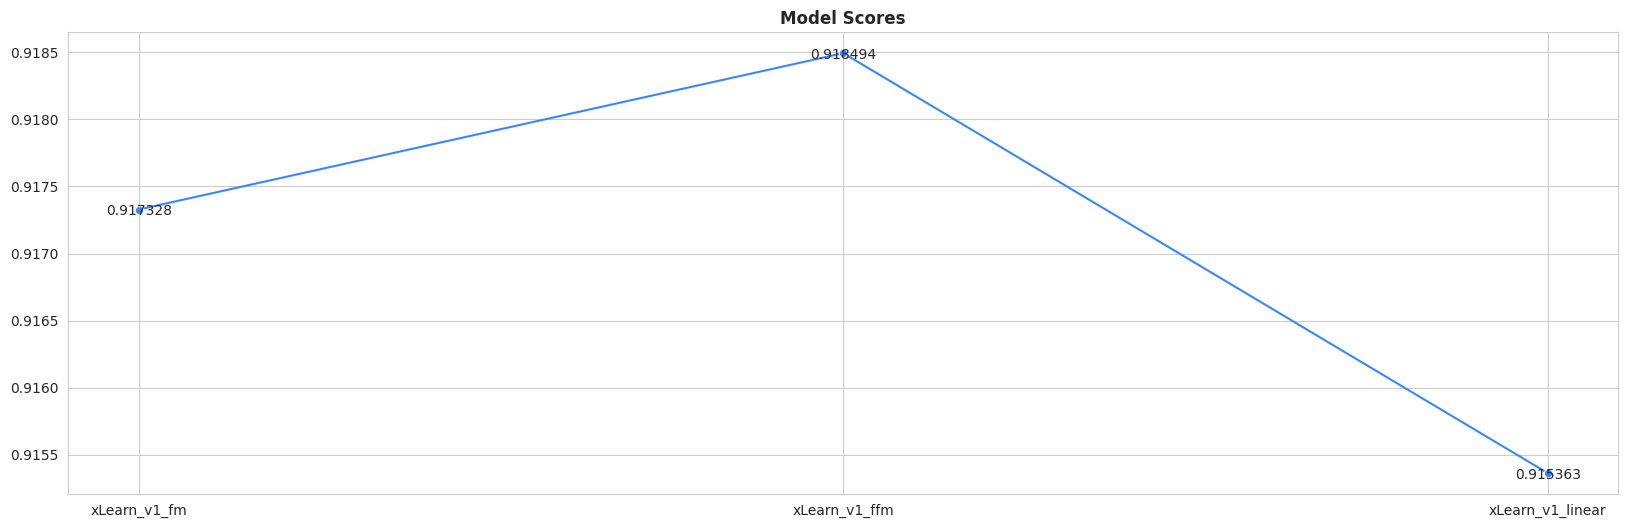

In [45]:
## -- Get models scores --
all_model_scores = {}

for k, v in all_model_predictions.items():
    for x, y in v.items():
        if x == 'score':
            all_model_scores[k] = y

plt.figure(figsize=(20, 6))
sns.lineplot(all_model_scores, marker='o')
# pd.Series(all_model_scores).plot(marker='o')
plt.title('Model Scores', fontweight='semibold')
plt.tick_params('x', rotation=0)

for i, score in enumerate(all_model_scores.values()):
    plt.text(float(i), score+5e-7, score, ha='center', va='center_baseline')

plt.show()

In [46]:
## -- Get oof predictions --
all_model_oof = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_oof = pd.concat([all_model_oof, pd.DataFrame({n: y})], axis=1)

all_model_oof.to_parquet(f"oof_{version_name}_models.parquet", index=False)

all_model_oof.head()

,xLearn_v1_fm_917328,xLearn_v1_ffm_918494,xLearn_v1_linear_915363
0,0.014478,0.009681,0.018932
1,0.001403,0.001613,0.001068
2,0.319649,0.270509,0.362853
3,0.793891,0.734752,0.785900
4,0.800225,0.770802,0.786853


In [47]:
## -- Get test predictions --
all_model_test = pd.DataFrame()

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'test_preds':
            n = f"{k}_{str(list(all_model_scores.values())[i]).split('.')[1]}"
            all_model_test = pd.concat([all_model_test, pd.DataFrame({n: y})], axis=1)

all_model_test.to_parquet(f"test_{version_name}_models.parquet", index=False)

all_model_test.head()

,xLearn_v1_fm_917328,xLearn_v1_ffm_918494,xLearn_v1_linear_915363
0,0.112108,0.125505,0.123370
1,0.001667,0.001787,0.001279
2,0.098866,0.096175,0.103373
3,0.003322,0.004284,0.005122
4,0.553081,0.562408,0.567104


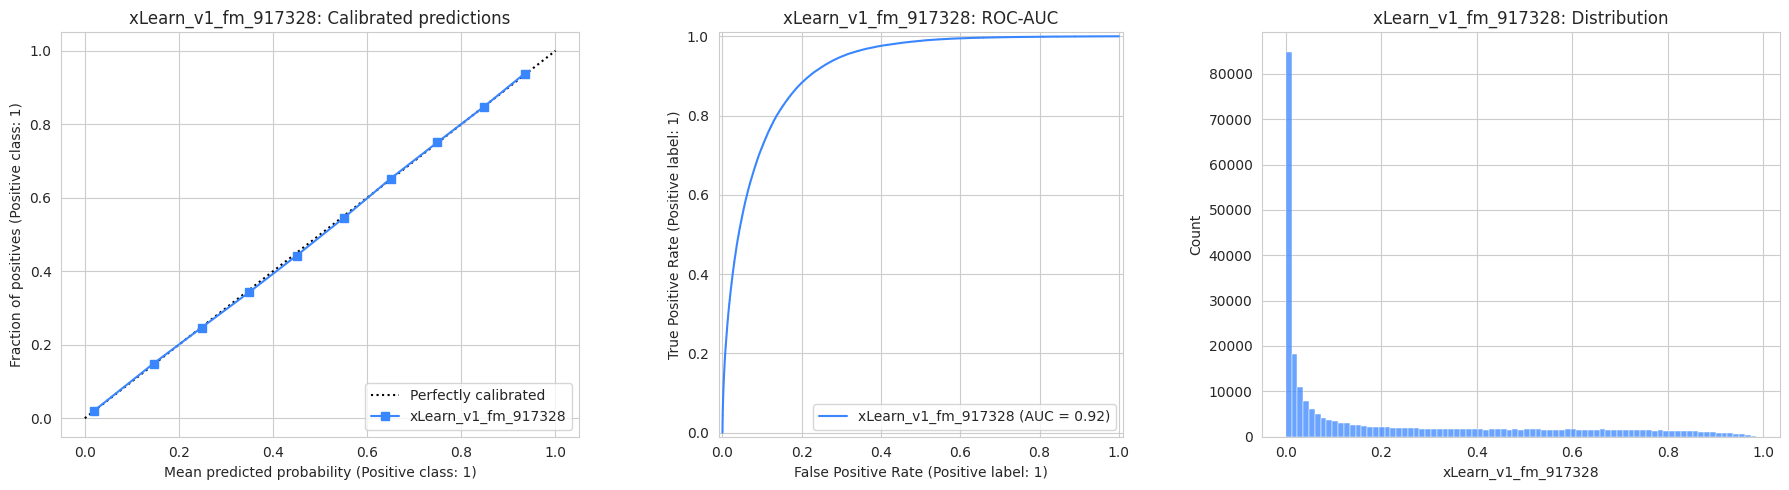

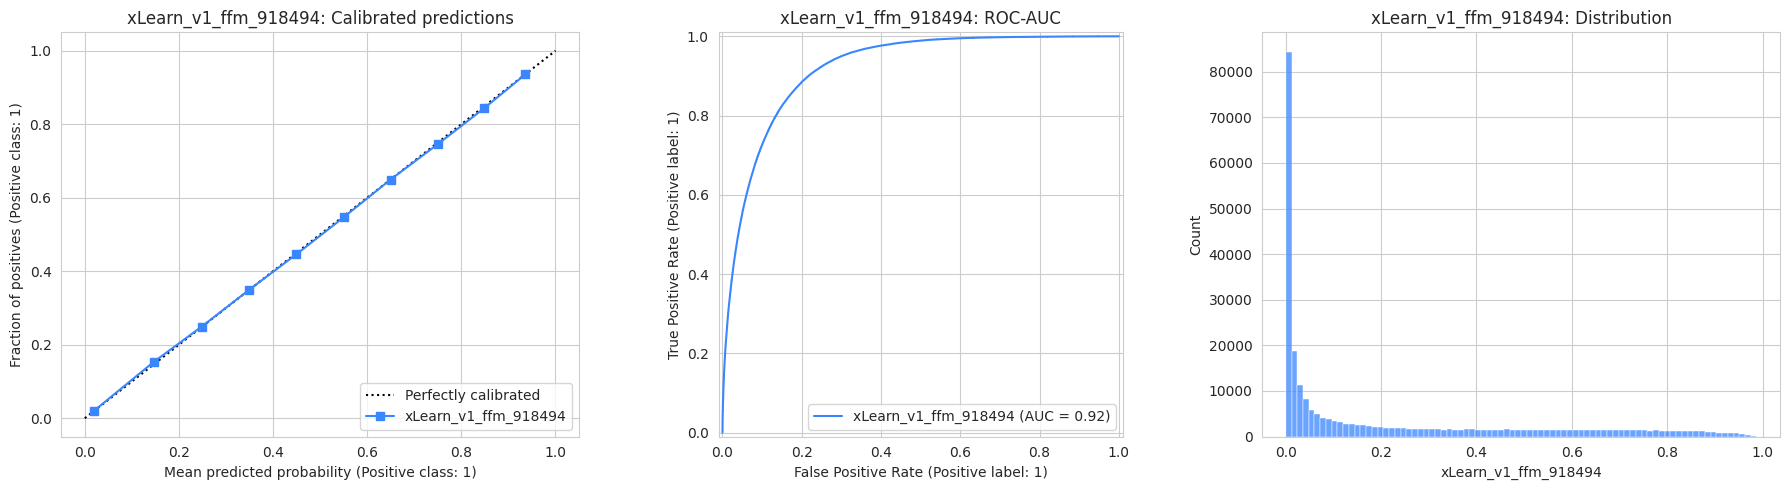

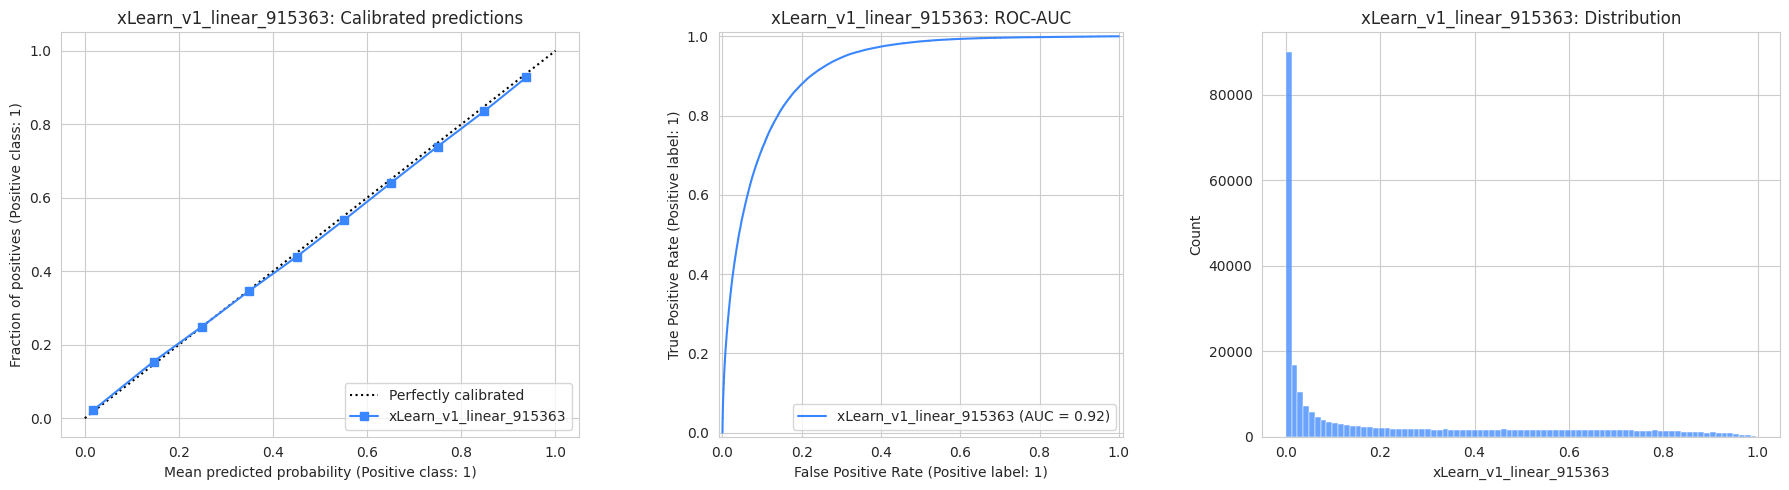

In [48]:
## -- PLOT PREDICTIONS --
for i, n in enumerate(all_model_test.columns):
    _, axs = plt.subplots(1, 3, figsize=(18, 5)) 

    CalibrationDisplay.from_predictions(data_size[TARGET], all_model_oof[n], n_bins=10, name=n, ax=axs[0])
    axs[0].set_title(f"{n}: Calibrated predictions")

    RocCurveDisplay.from_predictions(data_size[TARGET], all_model_oof[n], name=n, ax=axs[1])
    axs[1].set_title(f"{n}: ROC-AUC")
    # axs[1].grid(False)

    sns.histplot(all_model_test[n], ax=axs[2])
    axs[2].set_title(f"{n}: Distribution")

    plt.tight_layout()
    plt.show()
    print()